# B13 — Qiskit Tour: Circuits, Statevector, Operator

**Track B — the SDK.** Everything here maps onto something we built by hand in
Track A.

---

## Where we are

In A01–A06 we built qubits out of NumPy arrays: a state was a complex vector, a
gate was a matrix, and applying a gate was `M @ v`. Nothing was hidden, and
nothing was convenient.

Qiskit gives us the convenience back without changing any of the mathematics. The
job of this notebook is to line up the two vocabularies so that nothing in Track
B ever looks like magic:

| Track A (by hand) | Qiskit |
|---|---|
| complex vector `np.array([a, b])` | `Statevector` |
| gate matrix, e.g. `H = [[1,1],[1,-1]]/√2` | `Operator`, or `qc.h(0)` |
| `M @ v` | `Statevector(qc)` / `sv.evolve(op)` |
| `np.kron` in reverse order | `QuantumCircuit(n)` with qubit indices |
| sampling with `rng.choice` | `StatevectorSampler` / `SamplerV2` |
| your own matplotlib | `qiskit.visualization` |

## A warning that will save you hours

This repo pins **Qiskit 2.5**, and Qiskit 2.0 removed a great deal. If you have
read quantum tutorials before — or asked a language model for code — you have
almost certainly seen these, and **every one of them now raises**:

```python
from qiskit import execute            # gone in 1.0
Aer.get_backend('qasm_simulator')     # gone -> AerSimulator()
qc.x(1).c_if(creg, 1)                 # gone in 2.0 -> `with qc.if_test(...)`
from qiskit.algorithms import VQE     # gone in 1.0
from qiskit.opflow import X, Z        # gone in 1.0
from qiskit.primitives import Sampler # V1, gone in 2.0 -> StatevectorSampler
```

The current equivalents are used throughout this notebook. The full list lives in
`CLAUDE.md`, and the repo's build gate greps for every one of them, so nothing
stale can ship here.

In [1]:
from qviz import backends, grid, style

import matplotlib.pyplot as plt
import numpy as np
import qiskit
from qiskit import QuantumCircuit, transpile
from qiskit.circuit import ClassicalRegister, QuantumRegister
from qiskit.converters import circuit_to_dag
from qiskit.primitives import StatevectorSampler
from qiskit.quantum_info import Operator, Statevector, partial_trace
from qiskit.visualization import (array_to_latex, plot_bloch_multivector,
                                  plot_histogram, plot_state_city,
                                  plot_state_hinton, plot_state_paulivec,
                                  plot_state_qsphere)

style.use()

SEED = backends.seed_for("B13")
rng = np.random.default_rng(SEED)
print("qiskit", qiskit.__version__, " seed", SEED)

qiskit 2.5.1  seed 20260817


## A circuit is a recipe, not a state

The first genuine difference from Track A. There, we held a *state* and mutated
it. In Qiskit you build a `QuantumCircuit` — a **list of instructions** — and the
state only exists when you ask for it.

That indirection is what lets the same circuit be simulated, optimised for
hardware, or drawn.

In [2]:
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)

print(qc)
print("\ninstructions:", [inst.operation.name for inst in qc.data])
print("depth:", qc.depth(), " qubits:", qc.num_qubits, " ops:", qc.count_ops())

     ┌───┐     
q_0: ┤ H ├──■──
     └───┘┌─┴─┐
q_1: ─────┤ X ├
          └───┘

instructions: ['h', 'cx']
depth: 2  qubits: 2  ops: OrderedDict({'h': 1, 'cx': 1})


### Three ways to draw it

`draw('mpl')` is the one to use in a notebook. It needs `pylatexenc` installed —
if it is missing you get a `MissingOptionalLibraryError` rather than a fallback,
which is why `requirements.txt` pins `qiskit[visualization]` rather than bare
`qiskit`.

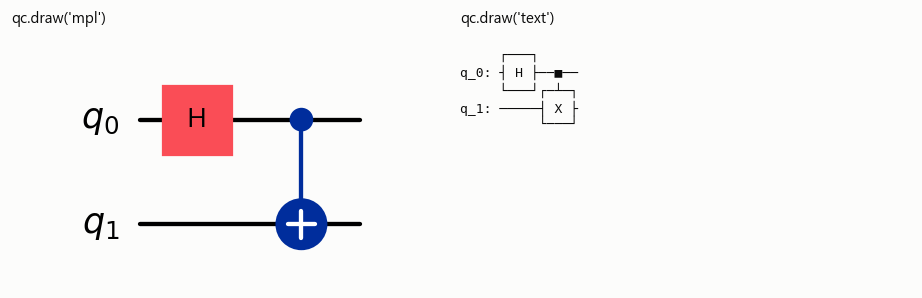

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(9.0, 2.6),
                         gridspec_kw={"width_ratios": [1.15, 1]})
qc.draw("mpl", ax=axes[0], style={"backgroundcolor": style.SURFACE})
axes[0].set_title("qc.draw('mpl')", loc="left", fontsize=10)

axes[1].axis("off")
axes[1].text(0.0, 0.95, str(qc.draw("text")), family="monospace", fontsize=8.5,
             va="top", color=style.INK)
axes[1].set_title("qc.draw('text')", loc="left", fontsize=10)
plt.show()

## `Statevector` is our complex vector

`Statevector(qc)` runs the circuit on the all-zeros input and hands back the
amplitude vector — the exact object we manipulated by hand in A01 and A05.

Note it takes the circuit *without* measurements. A measurement is not a unitary,
so a circuit containing one has no single statevector to report.

In [4]:
sv = Statevector(qc)
print("type:", type(sv).__name__, " dim:", sv.dim)
print("amplitudes:\n", grid.show_state(sv.data))

# The same numbers we would have computed by hand in Track A.
H = np.array([[1, 1], [1, -1]], dtype=complex) / np.sqrt(2)

# Build CNOT from its truth table rather than transcribing 16 numbers. Under the
# little-endian convention, index i has qubit k in bit k of i, so "control is
# qubit 0, target is qubit 1" means: if bit 0 is set, flip bit 1.
CNOT = np.zeros((4, 4), dtype=complex)
for i in range(4):
    q0, q1 = i & 1, (i >> 1) & 1
    j = i ^ (q0 << 1)          # flip qubit 1 iff qubit 0 is 1
    CNOT[j, i] = 1
    print(f"  |{q1}{q0}>  (index {i})  ->  index {j}")

by_hand = CNOT @ np.kron(np.eye(2), H) @ np.array([1, 0, 0, 0], dtype=complex)

print("\nby hand :", np.round(by_hand, 6))
print("qiskit  :", np.round(sv.data, 6))
print("match   :", np.allclose(by_hand, sv.data))

type: Statevector  dim: 4
amplitudes:
   |00>  +0.7071+0.0000j
  |11>  +0.7071+0.0000j
  |00>  (index 0)  ->  index 0
  |01>  (index 1)  ->  index 3
  |10>  (index 2)  ->  index 2
  |11>  (index 3)  ->  index 1

by hand : [0.707107+0.j 0.      +0.j 0.      +0.j 0.707107+0.j]
qiskit  : [0.707107+0.j 0.      +0.j 0.      +0.j 0.707107+0.j]
match   : True


Two endianness details are hiding in that cell, and both are places where code
runs happily while being wrong.

**The Kronecker order.** To put `H` on **qubit 0**, the identity comes **first**:
`np.kron(np.eye(2), H)`. Qiskit is little-endian, qubit 0 is the rightmost bit,
and so the tensor factors run in reverse of how you say them out loud.

**Which qubit is the control.** The obvious-looking CNOT matrix

```
[[1,0,0,0], [0,1,0,0], [0,0,0,1], [0,0,1,0]]
```

is the one printed in most textbooks — and in this convention it is
`cx(1, 0)`, not `cx(0, 1)`. It swaps indices 2 and 3, i.e. it flips qubit 0 when
qubit 1 is set. Building the matrix from its truth table above avoids the
question entirely, which is why we did.

Neither mistake raises an exception. Both produce a plausible-looking state that
happens to be a different one. B17 is devoted to the trap.

## `Operator` is our gate matrix

Where `Statevector` is the vector, `Operator` is the matrix — the full unitary a
circuit implements. It is how you check that two circuits do the same thing.

In [5]:
U = Operator(qc)
print("shape:", U.data.shape)
display(array_to_latex(U.data, prefix="U_{\\mathrm{bell}} = ", max_size=(6, 6)))

# Unitarity, verified rather than assumed.
print("U @ U.conj().T == I :", np.allclose(U.data @ U.data.conj().T, np.eye(4)))

# Two circuits, same unitary? CNOT == (I x H) . CZ . (I x H)
alt = QuantumCircuit(2)
alt.h(0)
alt.h(1)
alt.cz(0, 1)
alt.h(1)
print("\nH-CZ-H route equals the H-CNOT circuit:", Operator(alt).equiv(U))

shape: (4, 4)


<IPython.core.display.Latex object>

U @ U.conj().T == I : True

H-CZ-H route equals the H-CNOT circuit: True


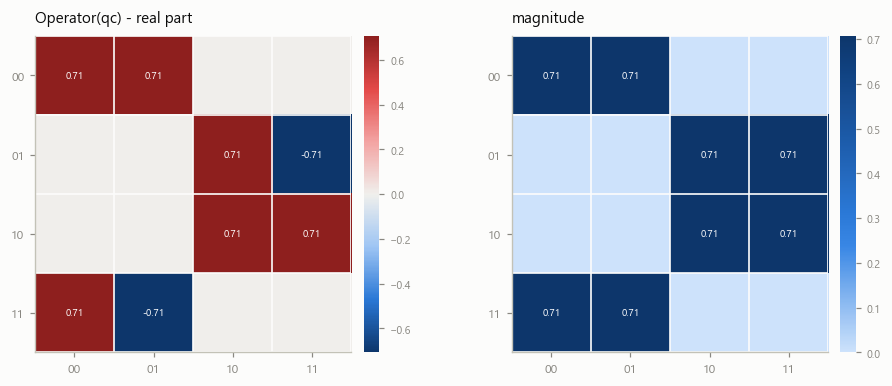

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(8.6, 3.4))
grid.matrix(axes[0], U.data, part="re", title="Operator(qc) - real part")
grid.matrix(axes[1], U.data, part="abs", title="magnitude")
plt.show()

## The index card: one state, five renderings

Qiskit ships several state visualizers and it is genuinely unobvious which to
reach for. Here is the same Bell state in all of them at once — come back to this
figure whenever you need to pick one.

- **city** — real and imaginary parts as 3D towers. Good for spotting structure in
  a density matrix; hard to read precise values off.
- **hinton** — area encodes magnitude. Excellent for watching off-diagonal terms
  die under noise (B26 leans on it).
- **paulivec** — the state expanded in the Pauli basis. This is the natural view
  when you care about expectation values, which is what an `Estimator` returns.
- **qsphere** — every basis state on one sphere, node size = probability, node
  colour = phase. The only one of the five that shows phase.
- **bloch multivector** — one Bloch sphere per qubit. Read the warning below.

**`plot_bloch_multivector` will mislead you on entangled states.** It plots each
qubit's *reduced* state. For a Bell state, each qubit alone is maximally mixed, so
both arrows collapse to zero length at the centre — the picture shows two qubits
that individually contain nothing while the pair contains everything. That is not
a rendering bug, it is the physics, and it is the single most important thing the
Bloch picture cannot show. B14 makes it explicit and B18 quantifies it.

C:\Users\thoma\quantum-under-the-hood\.venv\Lib\site-packages\qiskit\visualization\state_visualization.py:528: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


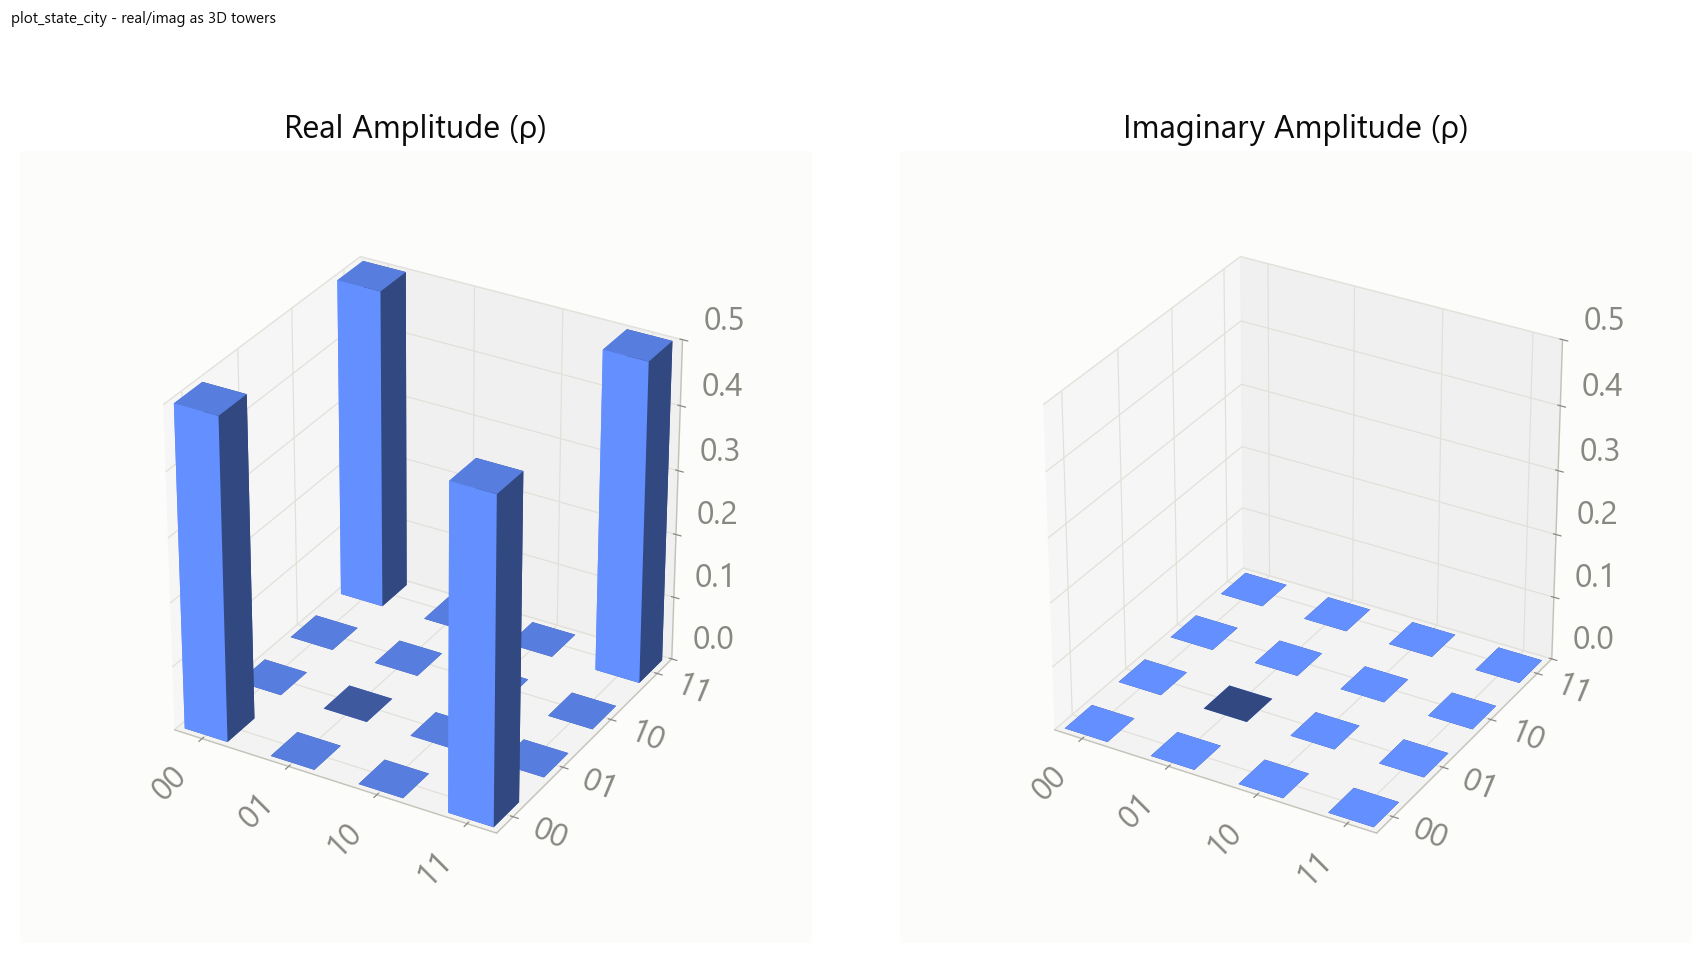

C:\Users\thoma\quantum-under-the-hood\.venv\Lib\site-packages\qiskit\visualization\state_visualization.py:177: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


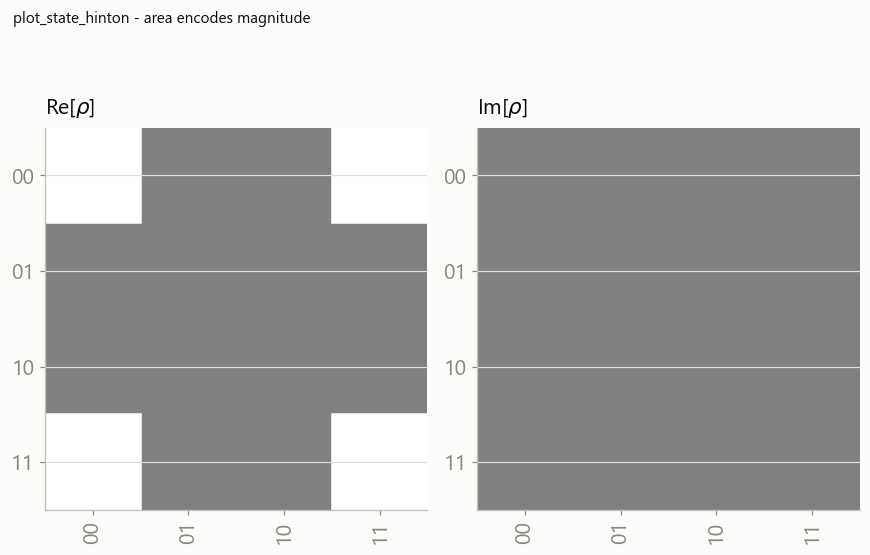

C:\Users\thoma\quantum-under-the-hood\.venv\Lib\site-packages\qiskit\visualization\state_visualization.py:747: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


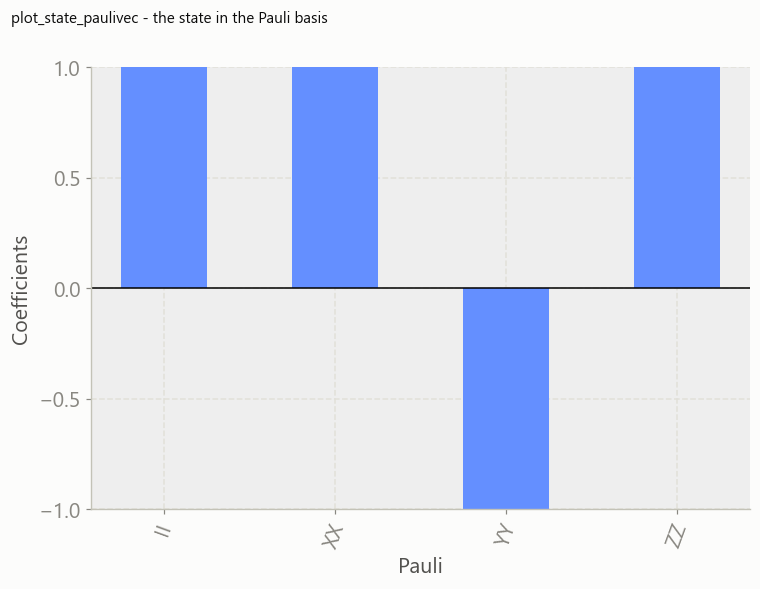

C:\Users\thoma\quantum-under-the-hood\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  fig.canvas.print_figure(bytes_io, **kw)


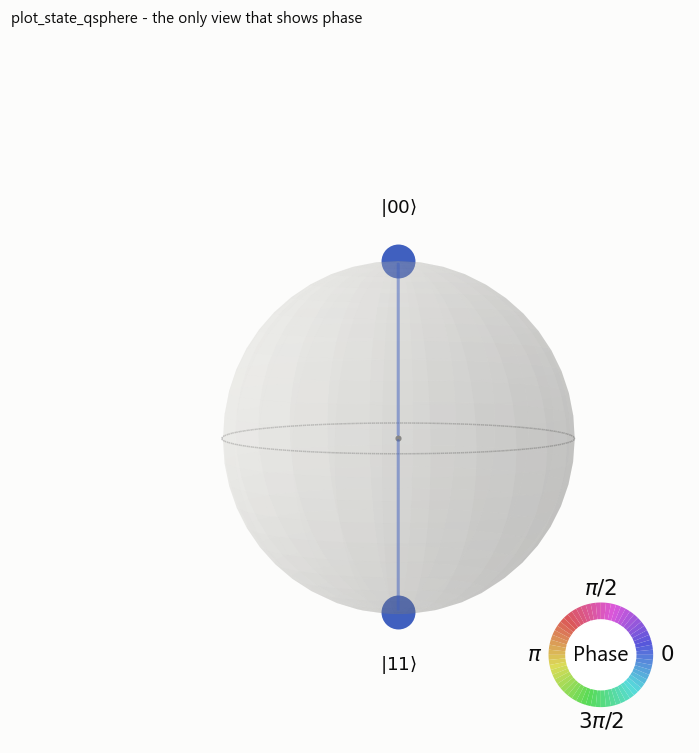

C:\Users\thoma\quantum-under-the-hood\.venv\Lib\site-packages\qiskit\visualization\state_visualization.py:369: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


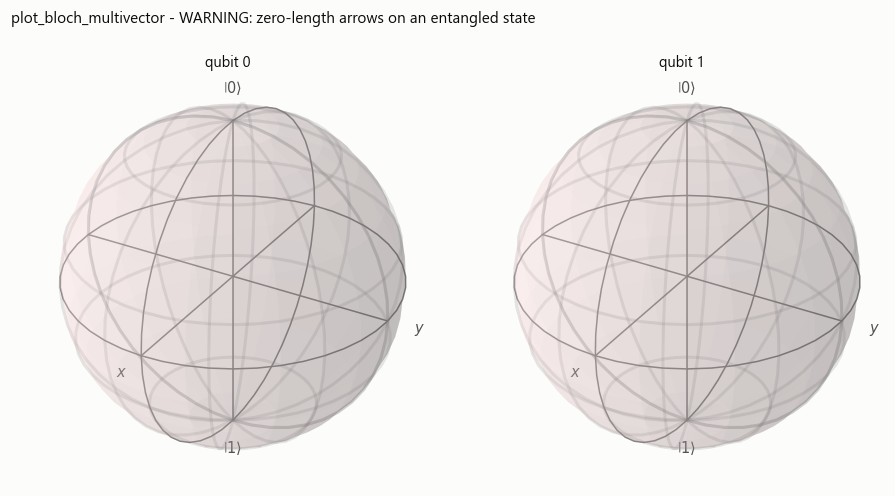

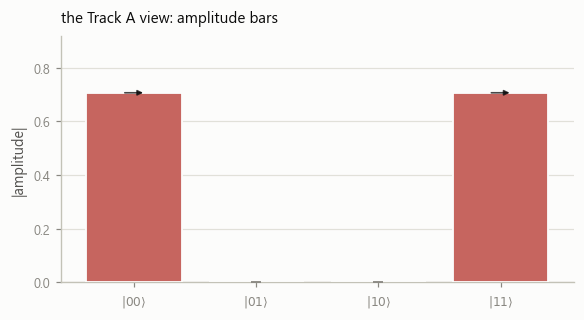

In [7]:
# Each Qiskit visualizer builds and styles its own Figure, so they are displayed
# one at a time rather than forced into shared subplots.
views = [
    (plot_state_city, "plot_state_city - real/imag as 3D towers"),
    (plot_state_hinton, "plot_state_hinton - area encodes magnitude"),
    (plot_state_paulivec, "plot_state_paulivec - the state in the Pauli basis"),
    (plot_state_qsphere, "plot_state_qsphere - the only view that shows phase"),
    (plot_bloch_multivector,
     "plot_bloch_multivector - WARNING: zero-length arrows on an entangled state"),
]

for fn, caption in views:
    f = fn(sv)
    # y above 1 keeps the caption clear of the visualizer's own subplot titles.
    f.suptitle(caption, x=0.02, y=1.06, ha="left", fontsize=10, color=style.INK)
    display(f)
    plt.close(f)          # close explicitly: 30 notebooks x many figures adds up

# ...and the Track A view, for comparison.
fig, ax = plt.subplots(figsize=(5.2, 2.8))
grid.amp_bars(ax, sv.data)
ax.set_title("the Track A view: amplitude bars", loc="left", fontsize=10)
plt.show()

In [8]:
# Why the Bloch arrows vanished, in numbers:
rho0 = partial_trace(sv, [1])
print("reduced state of qubit 0:\n", np.round(rho0.data, 4))
print("\npurity Tr(rho^2) =", round(float(rho0.purity().real), 4),
      " (1.0 = pure, 0.5 = maximally mixed for one qubit)")
print("Bloch vector length =",
      round(float(np.sqrt(sum(np.real(np.trace(rho0.data @ P)) ** 2 for P in [
          np.array([[0, 1], [1, 0]], dtype=complex),
          np.array([[0, -1j], [1j, 0]], dtype=complex),
          np.array([[1, 0], [0, -1]], dtype=complex)]))), 4))

reduced state of qubit 0:
 [[0.5+0.j 0. +0.j]
 [0. +0.j 0.5+0.j]]

purity Tr(rho^2) = 0.5  (1.0 = pure, 0.5 = maximally mixed for one qubit)
Bloch vector length = 0.0


A Bloch vector of length 0 means the qubit, considered on its own, is in a state
of total ignorance — every measurement on it is a fair coin. All of the
information lives in the *correlation* between the two qubits, and a per-qubit
picture has nowhere to put it.

## Sampling: primitives, not `execute()`

To get counts you attach measurements and run a **primitive**. `execute()` is
gone; so is Primitives V1 (`from qiskit.primitives import Sampler`).

The V2 API has one sharp edge worth stating plainly: results are addressed by the
**name of the classical register**. `measure_all()` creates one called `meas`, so
you would write `result[0].data.meas`. This repo instead declares
`ClassicalRegister(n, "c")` explicitly, so it is always `.data.c` — a convention
that saves a lot of `AttributeError`.

{'00': 2086, '11': 2010}


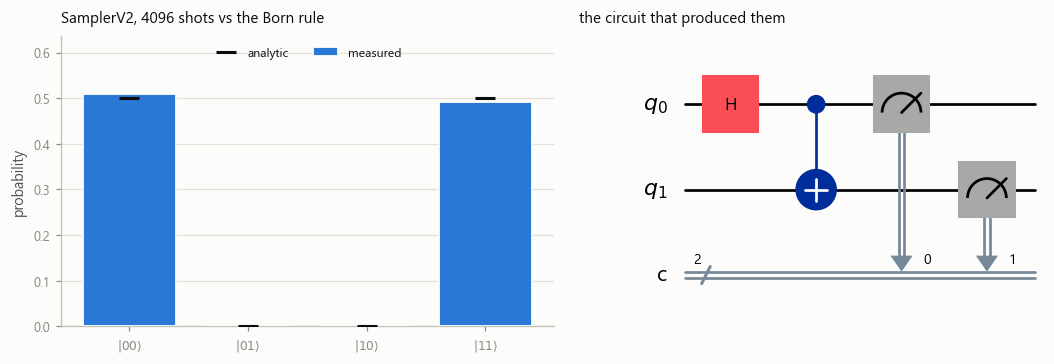

largest deviation from analytic: 0.0093


In [9]:
qr, cr = QuantumRegister(2, "q"), ClassicalRegister(2, "c")
qc_meas = QuantumCircuit(qr, cr)
qc_meas.h(0)
qc_meas.cx(0, 1)
qc_meas.measure([0, 1], [0, 1])

SHOTS = 4096
result = StatevectorSampler(seed=SEED).run([qc_meas], shots=SHOTS).result()
counts = result[0].data.c.get_counts()      # ".c" = the register's NAME
print(counts)

analytic = np.abs(sv.data) ** 2
measured = np.array([counts.get(format(i, "02b"), 0) / SHOTS for i in range(4)])

fig, axes = plt.subplots(1, 2, figsize=(9.6, 3.2))
grid.prob_bars(axes[0], measured, analytic=analytic)
axes[0].legend(loc="upper center", ncol=2, fontsize=8)
axes[0].set_title(f"SamplerV2, {SHOTS} shots vs the Born rule", loc="left",
                  fontsize=10)

qc_meas.draw("mpl", ax=axes[1], style={"backgroundcolor": style.SURFACE})
axes[1].set_title("the circuit that produced them", loc="left", fontsize=10)
plt.show()

print("largest deviation from analytic:", round(float(np.abs(measured - analytic).max()), 4))

The two outcomes `01` and `10` never appear. That is entanglement in its most
concrete form: the qubits are individually random but perfectly correlated. B18
and B19 pursue exactly this until it becomes a testable, falsifiable claim about
the world.

## Deep dive — a circuit is really a graph

*Skip on a first read.*

Internally a circuit is a **directed acyclic graph** of operations, not a list.
That is what lets the transpiler reorder, cancel and re-route gates: two gates on
disjoint qubits are simply unordered with respect to each other.

C30 makes this the subject; here is a first look.

op nodes: 5  depth: 3  (5 gates but depth 3 - parallelism is visible to the DAG)


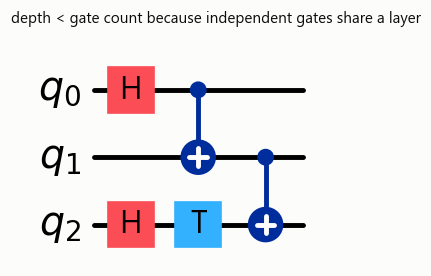

  layer 0: ['h', 'h']
  layer 1: ['cx', 't']
  layer 2: ['cx']


In [10]:
deep = QuantumCircuit(3)
deep.h(0)
deep.h(2)          # independent of the h(0) - the DAG shows they are unordered
deep.cx(0, 1)
deep.t(2)
deep.cx(1, 2)

dag = circuit_to_dag(deep)
print("op nodes:", len(dag.op_nodes()), " depth:", deep.depth(),
      " (5 gates but depth", deep.depth(), "- parallelism is visible to the DAG)")

fig, ax = plt.subplots(figsize=(6.4, 2.4))
deep.draw("mpl", ax=ax, style={"backgroundcolor": style.SURFACE})
ax.set_title("depth < gate count because independent gates share a layer",
             loc="left", fontsize=10)
plt.show()

for layer_i, layer in enumerate(dag.layers()):
    names = [n.op.name for n in layer["graph"].op_nodes()]
    print(f"  layer {layer_i}: {names}")

## What this tour glossed over

- **`Statevector` does not scale.** It is a dense `2^n` array, exactly like ours.
  It is a teaching and debugging tool, not a way to run big circuits, and on real
  hardware you never get one at all — only counts. A07 measures the wall.
- **`plot_bloch_multivector` cannot show entanglement**, as above. Treat a
  zero-length arrow as a flag, not a failure.
- **`Operator(qc)` builds the full `2^n × 2^n` matrix.** Fine for 2–3 qubits,
  hopeless past ~12.
- **Shots are not free.** Every probability here carries `1/√N` error (A04), and
  on hardware shots cost queue time.
- **We used no real hardware and no noise.** Every number in this notebook is
  from an ideal simulator. B26 and C27 are where that assumption is dismantled.

## Checkpoint

Track B notebooks close by asserting against the Track A result they mirror. That
cross-check is the repo's regression test: if a convention drifts on either side,
this cell fails.

In [11]:
# 1. Qiskit's statevector matches the hand-built matrix product (A01/A05/A06).
assert np.allclose(by_hand, sv.data)

# 2. Little-endian contract: X on qubit 0 of two qubits lands on index 1, |01>.
probe = QuantumCircuit(2)
probe.x(0)
assert int(np.argmax(np.abs(Statevector(probe).data))) == 1

# 3. Operator is unitary, and the two Bell circuits agree.
assert np.allclose(U.data @ U.data.conj().T, np.eye(4))
assert Operator(alt).equiv(U)

# 4. Born rule: sampled frequencies match |amplitude|^2 within shot noise.
#    5 sigma on 4096 shots is comfortably above the ~0.008 one-sigma scale.
assert np.abs(measured - analytic).max() < 5 * np.sqrt(0.25 / SHOTS)

# 5. Each qubit of a Bell state is maximally mixed - purity exactly 1/2.
assert np.isclose(float(partial_trace(sv, [1]).purity().real), 0.5)

# 6. The forbidden outcomes really are forbidden.
assert counts.get("01", 0) == 0 and counts.get("10", 0) == 0

print("B13 checkpoint passed.")

B13 checkpoint passed.


---

**Next:** [B14 — The Visualization Suite](B14_Visualization_Suite.ipynb), which
takes the five renderings above and works out when each one tells the truth.